<a href="https://colab.research.google.com/github/Gustavo-Bruges/ciencia-de-datos-unab/blob/main/analizando_datos_de_registo_cardiovascular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATOS REGICOR
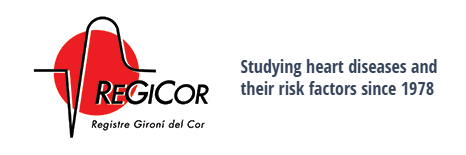



Este cuaderno está diseñado para practicar **pandas** con un conjunto de datos clínicos tipo REGICOR.

Estructura:
1) Carga del dataset
2) Preguntas por secciones
3) Cada pregunta incluye una celda de código para resolver

Notas:
- Si estás en **Google Colab**, puedes cargar el archivo manualmente o montarlo desde Drive.
- Si estás en un entorno local/Jupyter, ajusta la ruta del archivo.


## **Variables del conjunto de datos REGICOR**

| Variable | Descripción |
|----------|-------------|
| **id** | Identificador del individuo |
| **year** | Factor con niveles 1995, 2000 y 2005. Año de reclutamiento |
| **age** | Edad del paciente en la fecha de reclutamiento |
| **sex** | Factor con niveles *male* y *female*. Sexo |
| **smoker** | Factor con niveles *Never smoker*, *Current or former < 1y*, *Never or former ≥ 1y*. Estado de tabaquismo |
| **sbp** | Presión arterial sistólica |
| **dbp** | Presión arterial diastólica |
| **histhtn** | Factor con niveles *Yes* y *No*. Antecedente de hipertensión |
| **txhtn** | Factor con niveles *No* y *Yes*. Tratamiento para hipertensión (HTA) |
| **chol** | Colesterol total (mg/dL) |
| **hdl** | Colesterol HDL (mg/dL) |
| **triglyc** | Triglicéridos (mg/dL) |
| **ldl** | Colesterol LDL (mg/dL) |
| **histchol** | Factor con niveles *Yes* y *No*. Antecedente de hipercolesterolemia |
| **txchol** | Factor con niveles *No* y *Yes*. Tratamiento para colesterol |
| **height** | Talla (cm) |
| **weight** | Peso (kg) |
| **phyact** | Actividad física (kcal/semana) |
| **pcs** | Resumen del componente físico (*Physical Component Summary*) |
| **mcs** | Resumen del componente mental (*Mental Component Summary*) |
| **death** | Factor con niveles *No* y *Yes*. Mortalidad global |
| **todeath** | Días hasta la muerte por cualquier causa o hasta el final del seguimiento |
| **cv** | Factor con niveles *No* y *Yes*. Evento cardiovascular |
| **tocv** | Días hasta evento cardiovascular o hasta el final del seguimiento |

## Nota
Las variables **death**, **todeath**, **cv** y **tocv** fueron simuladas aleatoriamente para completar el conjunto de datos con variables de tiempo hasta evento.

## Fuente
Por razones de confidencialidad, el conjunto completo de datos no está disponible públicamente.  
Para más información: **www.regicor.org**

In [1]:
#TRABAJO CON PANDAS DESDE GOOGLEDRIVE
"""
Análisis de datos REGICOR con pandas y seaborn
Para ejecutar en IPython/Jupyter Notebook
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para notebooks
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11


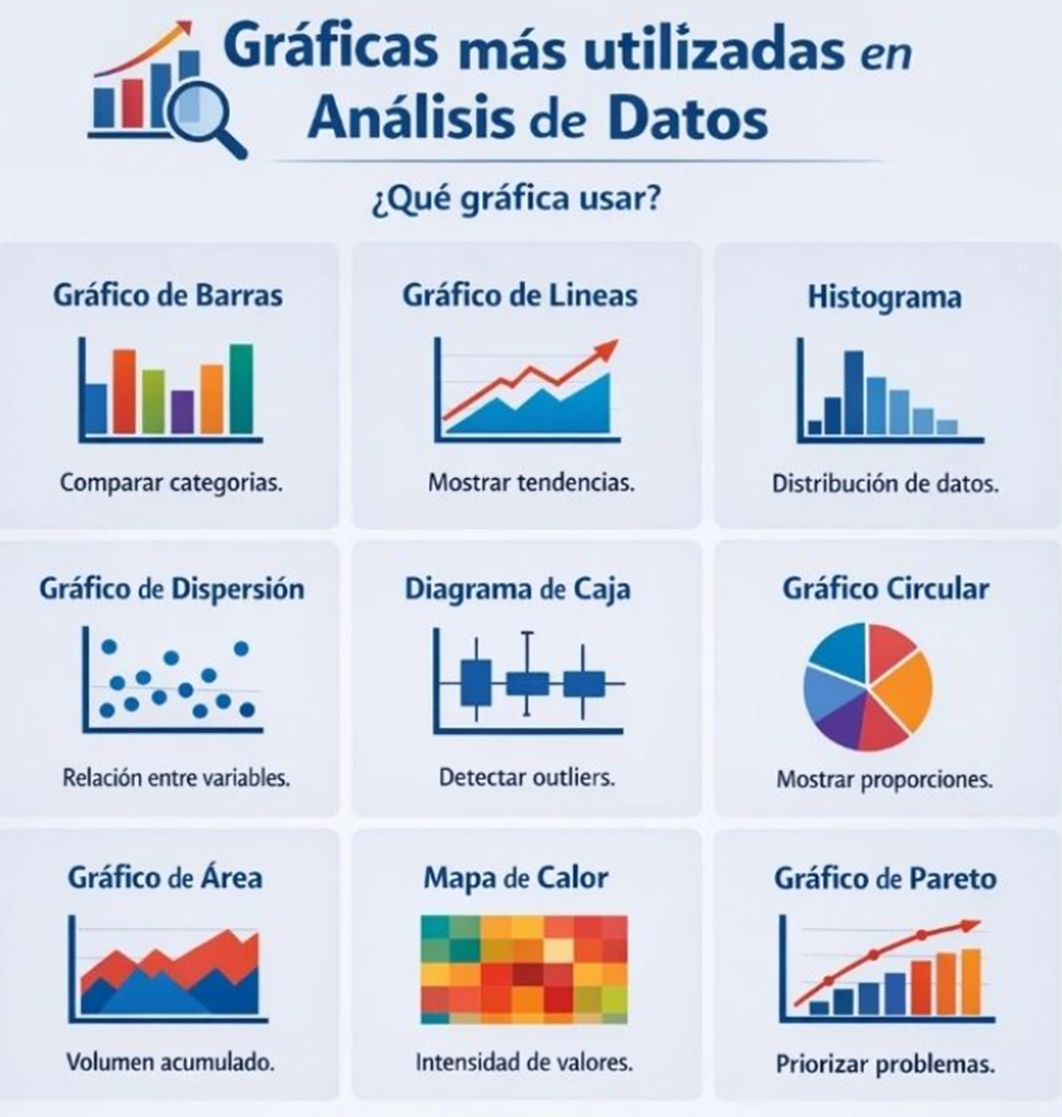


In [5]:
#En carpeta drive ya podemos asociarla a nuestro cuaderno
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/drive/MyDrive/ciencia_de_datos")

#CONFIRMO LA CARGA DE LA CARPETA
print(os.getcwd())

#LISTO LOS ARCHIVOS QUE TENGO EN EL DIRECTORIO
print(os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ciencia_de_datos
['netflix_data.csv', 'Untitled0.ipynb', 'stations.p', 'actors_movies.csv', 'casts.p', 'crews.p', 'taglines.p', 'S&P500.csv', 'WorldBank_GDP.csv', 'WorldBank_POP.csv', 'taxi_owners.csv', 'taxi_vehicles.csv', 'Chicago_wards.csv', 'Chicago_census.csv', 'licenses.csv', 'zip_demo.csv', 'business_owners.csv', 'land_use.csv', 'cta_ridership.csv', 'cta_calendar.csv', 'movies.csv', 'ratings.csv', 'movie_to_genres.csv', 'sequels.csv', 'financials.csv', 'biometria.csv', 'police.csv', 'policies.parquet', 'Copia de regicor (1).csv', 'Copia de regicor.csv']


In [6]:

# ============================================================
# CARGAR DATOS
# ============================================================
regicor = pd.read_csv('Copia de regicor.csv')

print("="*60)
print("ANÁLISIS DE DATOS REGICOR")
print("="*60)
print(f"\nDimensiones: {regicor.shape[0]} filas x {regicor.shape[1]} columnas")


ANÁLISIS DE DATOS REGICOR

Dimensiones: 2294 filas x 24 columnas


In [ ]:
# ============================================================
# 1. INFORMACIÓN GENERAL
# ============================================================
print("\n" + "="*60)
print("1. INFORMACIÓN GENERAL DEL DATASET")
print("="*60)

print("\nColumnas:")
print(regicor.info())


print("\nPrimeras filas:")
regicor.head()


1. INFORMACIÓN GENERAL DEL DATASET

Columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2294 entries, 0 to 2293
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        2294 non-null   int64  
 1   year      2294 non-null   int64  
 2   age       2294 non-null   int64  
 3   sex       2294 non-null   object 
 4   smoker    2233 non-null   object 
 5   sbp       2280 non-null   float64
 6   dbp       2280 non-null   float64
 7   histhtn   2286 non-null   object 
 8   txhtn     2251 non-null   object 
 9   chol      2193 non-null   float64
 10  hdl       2225 non-null   float64
 11  triglyc   2231 non-null   float64
 12  ldl       2126 non-null   float64
 13  histchol  2273 non-null   object 
 14  txchol    2239 non-null   object 
 15  height    2259 non-null   float64
 16  weight    2259 non-null   float64
 17  phyact    2206 non-null   float64
 18  pcs       2054 non-null   float64
 19  mcs       2054 non-nul

,id,year,age,sex,smoker,sbp,dbp,histhtn,txhtn,chol,...,txchol,height,weight,phyact,pcs,mcs,cv,tocv,death,todeath
0,2265,2005,70,Female,Never smoker,138.0,75.0,No,No,294.0,...,No,160.0,64.0,304.200000,54.455,58.918,No,1024.882428,Yes,1299.163435
1,1882,2005,56,Female,Never smoker,139.0,89.0,No,No,220.0,...,No,163.0,67.0,160.300000,58.165,47.995,No,2756.848506,No,39.326294
2,3000105616,2000,37,Male,Current or former < 1y,132.0,82.0,No,No,245.0,...,No,170.0,70.0,552.791209,43.429,62.585,No,1905.968789,No,858.422034
3,3000103485,2000,69,Female,Never smoker,168.0,97.0,No,No,168.0,...,No,147.0,68.0,522.000000,54.325,57.900,No,1055.379623,No,1833.076187
4,3000103963,2000,70,Female,NaN,NaN,NaN,No,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
columnas_numericas = regicor.select_dtypes([float, int]).columns
print('columnas numericas')
print(columnas_numericas)

columnas numericas
Index(['id', 'year', 'age', 'sbp', 'dbp', 'chol', 'hdl', 'triglyc', 'ldl',
       'height', 'weight', 'phyact', 'pcs', 'mcs', 'tocv', 'todeath'],
      dtype='object')


In [25]:
columnas_categoricas = regicor.select_dtypes('object').columns
print('columnas categoricas')
print(columnas_categoricas)

columnas categoricas
Index(['sex', 'smoker', 'histhtn', 'txhtn', 'histchol', 'txchol', 'cv',
       'death'],
      dtype='object')


In [9]:
columnas_categoricas

Index(['sex', 'smoker', 'histhtn', 'txhtn', 'histchol', 'txchol', 'cv',
       'death'],
      dtype='object')

In [39]:
#Para todas las  columnas tipo objeto las convierot a category
regicor[columnas_categoricas]= regicor[columnas_categoricas].astype('category')

In [40]:
#con el método .info() verificamos la conversión a categorias
regicor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2294 entries, 0 to 2293
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        2294 non-null   int64   
 1   year      2294 non-null   int64   
 2   age       2294 non-null   int64   
 3   sex       2294 non-null   category
 4   smoker    2233 non-null   category
 5   sbp       2280 non-null   float64 
 6   dbp       2280 non-null   float64 
 7   histhtn   2286 non-null   category
 8   txhtn     2251 non-null   category
 9   chol      2193 non-null   float64 
 10  hdl       2225 non-null   float64 
 11  triglyc   2231 non-null   float64 
 12  ldl       2126 non-null   float64 
 13  histchol  2273 non-null   category
 14  txchol    2239 non-null   category
 15  height    2259 non-null   float64 
 16  weight    2259 non-null   float64 
 17  phyact    2206 non-null   float64 
 18  pcs       2054 non-null   float64 
 19  mcs       2054 non-null   float64 
 20  cv      

In [19]:
range(1,100)

In [30]:
columnas_categoricas = ['sex', 'smoker', 'histhtn', 'txhtn', 'histchol', 'txchol', 'cv','death']

In [44]:
regicor.sex.cat.categories

Index(['Female', 'Male'], dtype='object')

In [47]:
#se hace for loop para ver todas los niveles de nuestras variables categóricas
for col in columnas_categoricas:
  print(col)
  print(regicor[col].cat.categories)
  print(' ')



sex
Index(['Female', 'Male'], dtype='object')
 
smoker
Index(['Current or former < 1y', 'Former >= 1y', 'Never smoker'], dtype='object')
 
histhtn
Index(['No', 'Yes'], dtype='object')
 
txhtn
Index(['No', 'Yes'], dtype='object')
 
histchol
Index(['No', 'Yes'], dtype='object')
 
txchol
Index(['No', 'Yes'], dtype='object')
 
cv
Index(['No', 'Yes'], dtype='object')
 
death
Index(['No', 'Yes'], dtype='object')
 


In [49]:
regicor.describe(include='category')

,sex,smoker,histhtn,txhtn,histchol,txchol,cv,death
count,2294,2233,2286,2251,2273,2239,2163,2148
unique,2,3,2,2,2,2,2,2
top,Female,Never smoker,No,No,No,No,No,No
freq,1193,1201,1563,1823,1564,2011,2071,1975


In [56]:

# ============================================================
# 2. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================
print("\n" + "="*60)
print("2. ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)

columnas_numericas
regicor[columnas_numericas].describe().round(2)

print("\nDistribución por sexo:")
print(regicor['sex'].value_counts())
print(f"\nPorcentaje:")
print((regicor['sex'].value_counts(normalize=True) * 100).round(2))

print("\nDistribución por año:")
print(regicor['year'].value_counts().sort_index())

print("\nDistribución por estado de fumador:")
print(regicor['smoker'].value_counts())





2. ESTADÍSTICAS DESCRIPTIVAS

Distribución por sexo:
sex
Female    1193
Male      1101
Name: count, dtype: int64

Porcentaje:
sex
Female    52.01
Male      47.99
Name: proportion, dtype: float64

Distribución por año:
year
1995     431
2000     786
2005    1077
Name: count, dtype: int64

Distribución por estado de fumador:
smoker
Never smoker              1201
Current or former < 1y     593
Former >= 1y               439
Name: count, dtype: int64


In [59]:
regicor.isnull().sum()

,0
id,0
year,0
age,0
sex,0
smoker,61
sbp,14
dbp,14
histhtn,8
txhtn,43
chol,101


In [ ]:


# ============================================================
# 3. VALORES FALTANTES
# ============================================================
print("\n" + "="*60)
print("3. ANÁLISIS DE VALORES FALTANTES")
print("="*60)

missing = regicor.isnull().sum()
missing_pct = (missing / len(regicor) * 100).round(2)
missing_regicor = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_pct})
missing_regicor = missing_regicor[missing_regicor['Faltantes'] > 0].sort_values('Porcentaje', ascending=False)
print("\nVariables con valores faltantes:")
missing_regicor



3. ANÁLISIS DE VALORES FALTANTES

Variables con valores faltantes:


,Faltantes,Porcentaje
mcs,240,10.46
pcs,240,10.46
ldl,168,7.32
death,146,6.36
todeath,146,6.36
tocv,131,5.71
cv,131,5.71
chol,101,4.40
phyact,88,3.84
hdl,69,3.01


In [65]:
columnas_numericas

Index(['id', 'year', 'age', 'sbp', 'dbp', 'chol', 'hdl', 'triglyc', 'ldl',
       'height', 'weight', 'phyact', 'pcs', 'mcs', 'tocv', 'todeath'],
      dtype='object')

In [67]:
columnas_numericas[2:6]

Index(['age', 'sbp', 'dbp', 'chol'], dtype='object')

In [68]:
# ============================================================
# 4. ANÁLISIS POR GRUPOS
# ============================================================
print("\n" + "♥ "*60)
print("4. ANÁLISIS POR GRUPOS")
print("♥ "*60)

print("\nEstadísticas por sexo:")
print(regicor.groupby('sex')[columnas_numericas].mean().round(2))

print("\nEstadísticas por año:")
print(regicor.groupby('year')[columnas_numericas[2:6]].mean().round(2))

print("\nEstadísticas por estado de fumador:")
print(regicor.groupby('smoker')[['age', 'sbp', 'chol', 'hdl']].mean().round(2))



♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ 
4. ANÁLISIS POR GRUPOS
♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ 

Estadísticas por sexo:
                  id     year    age     sbp    dbp    chol    hdl  triglyc  \
sex                                                                           
Female  1.184445e+09  2001.45  54.69  128.51  77.80  220.13  57.49   101.50   
Male    1.249812e+09  2001.36  54.78  134.04  81.66  217.28  47.55   130.73   

           ldl  height  weight  phyact    pcs    mcs     tocv  todeath  
sex                                                                     
Female  141.87  156.99   67.58  391.63  48.26  45.73  1764.18  1761.97  
Male    144.77  169.27   79.72  406.62  51.05  50.35  1744.43  1677.17  

Estadísticas por año:
        age     sbp    dbp    chol
year                              
1995  54

In [72]:
#Tabulacion cruzada, la cual se realiza con variables categóricas, se pueden considerar los marginales
pd.crosstab(regicor['sex'], regicor['smoker'], margins= True)

smoker,Current or former < 1y,Former >= 1y,Never smoker,All
sex,,,,
Female,183,79,900,1162
Male,410,360,301,1071
All,593,439,1201,2233


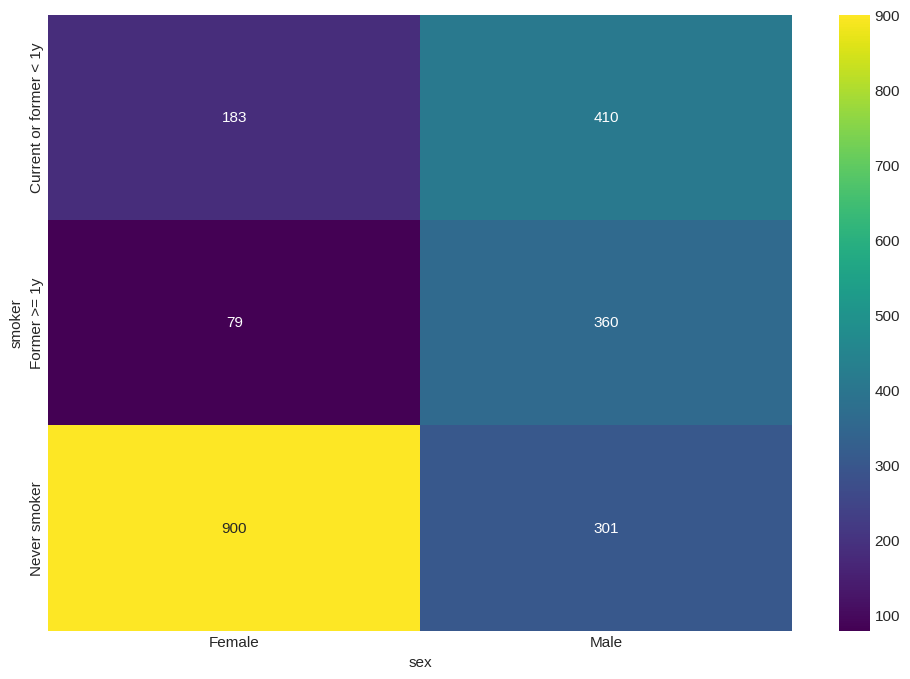

In [77]:

#Mapa de calor para  la tabla cruzada.
sns.heatmap(pd.crosstab(regicor['smoker'],regicor['sex']),annot=True, cmap="viridis",fmt="d")
plt.show()

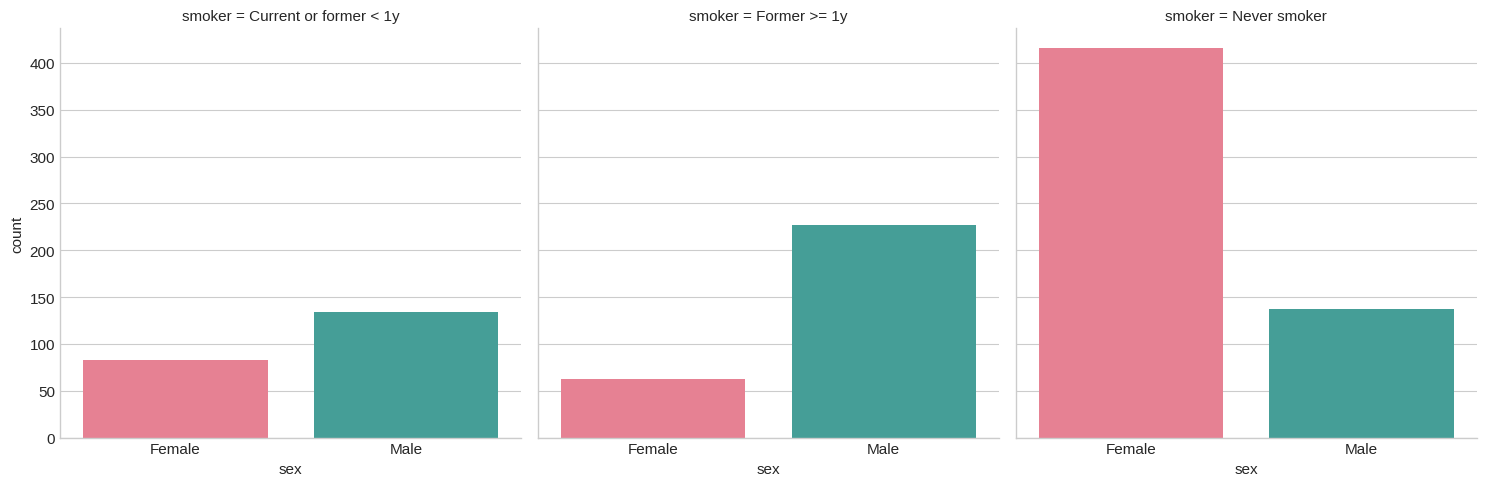

In [79]:
#Una forma alternativa es hacer un gráfico categórico

sns.catplot(data= regicor.query('year == 2005'), x = 'sex', kind= 'count', col= 'smoker', hue = 'sex', palette= 'husl')
plt.show()

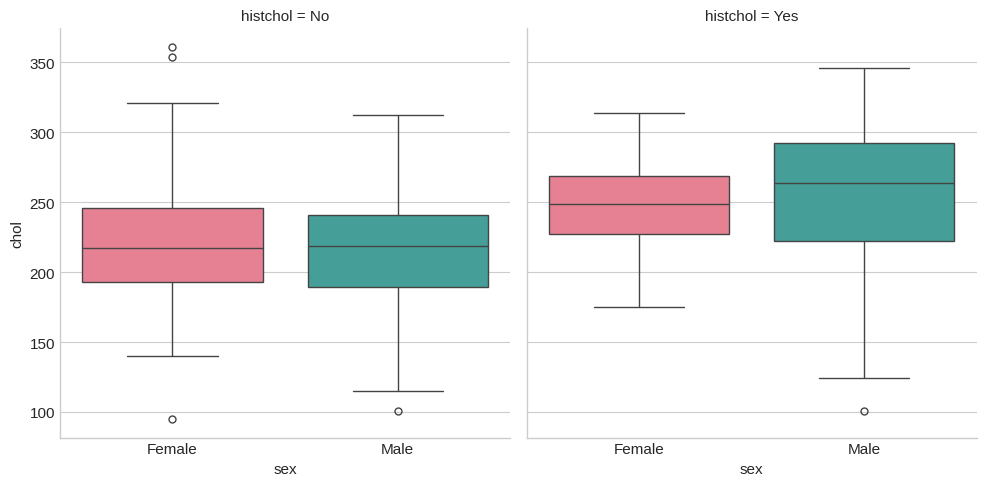

In [85]:
sns.catplot(data = regicor.query('year == 1995'), x = 'sex', y = 'chol',  kind= 'box', hue = 'sex', palette='husl', col = 'histchol' )
plt.show()

In [ ]:
def imc(peso,altura):
  '''Calculo del índice de masa corporal
  el peso en Kg y la altura en metros'''
  return peso/(altura/100)**2

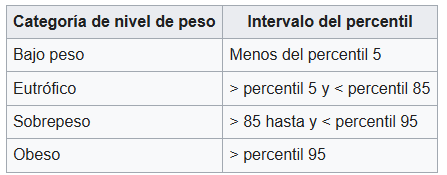

In [ ]:
percentiles = regicor["bmi"].quantile([0.05, 0.85, 0.95]).to_list()
p5, p85, p95 = percentiles

In [ ]:
bins = [-float("inf"), p5, p85, p95, float("inf")]

In [ ]:
labels = ["Bajo peso", "Normal", "Sobrepeso", "Obeso"]

In [ ]:
regicor["clasif"] = pd.cut(
    regicor["bmi"],
    bins=bins,
    labels=labels
)

In [ ]:
regicor[['bmi', 'clasif']].head()
regicor[['bmi', 'clasif']].tail()

,bmi,clasif
2289,21.461937,Normal
2290,27.681661,Normal
2291,28.546713,Normal
2292,26.838648,Normal
2293,24.242424,Normal


In [ ]:

# ============================================================
# 5. CORRELACIONES
# ============================================================
print("\n" + "="*60)
print("5. MATRIZ DE CORRELACIONES")
print("="*60)

corr_cols = ['age', 'sbp', 'dbp', 'chol', 'hdl', 'triglyc', 'ldl', 'height', 'weight']
corr_matrix = regicor[corr_cols].corr()
print("\nMatriz de correlación:")
corr_matrix.round(3)



5. MATRIZ DE CORRELACIONES

Matriz de correlación:


,age,sbp,dbp,chol,hdl,triglyc,ldl,height,weight
age,1.000,0.489,0.211,0.104,0.023,0.045,0.092,-0.243,0.053
sbp,0.489,1.000,0.660,0.176,-0.070,0.195,0.158,-0.061,0.258
dbp,0.211,0.660,1.000,0.155,-0.085,0.192,0.148,0.063,0.330
chol,0.104,0.176,0.155,1.000,0.199,0.316,0.948,-0.059,0.052
hdl,0.023,-0.070,-0.085,0.199,1.000,-0.366,-0.022,-0.247,-0.348
triglyc,0.045,0.195,0.192,0.316,-0.366,1.000,0.249,0.112,0.284
ldl,0.092,0.158,0.148,0.948,-0.022,0.249,1.000,-0.008,0.093
height,-0.243,-0.061,0.063,-0.059,-0.247,0.112,-0.008,1.000,0.509
weight,0.053,0.258,0.330,0.052,-0.348,0.284,0.093,0.509,1.000



6. VISUALIZACIONES


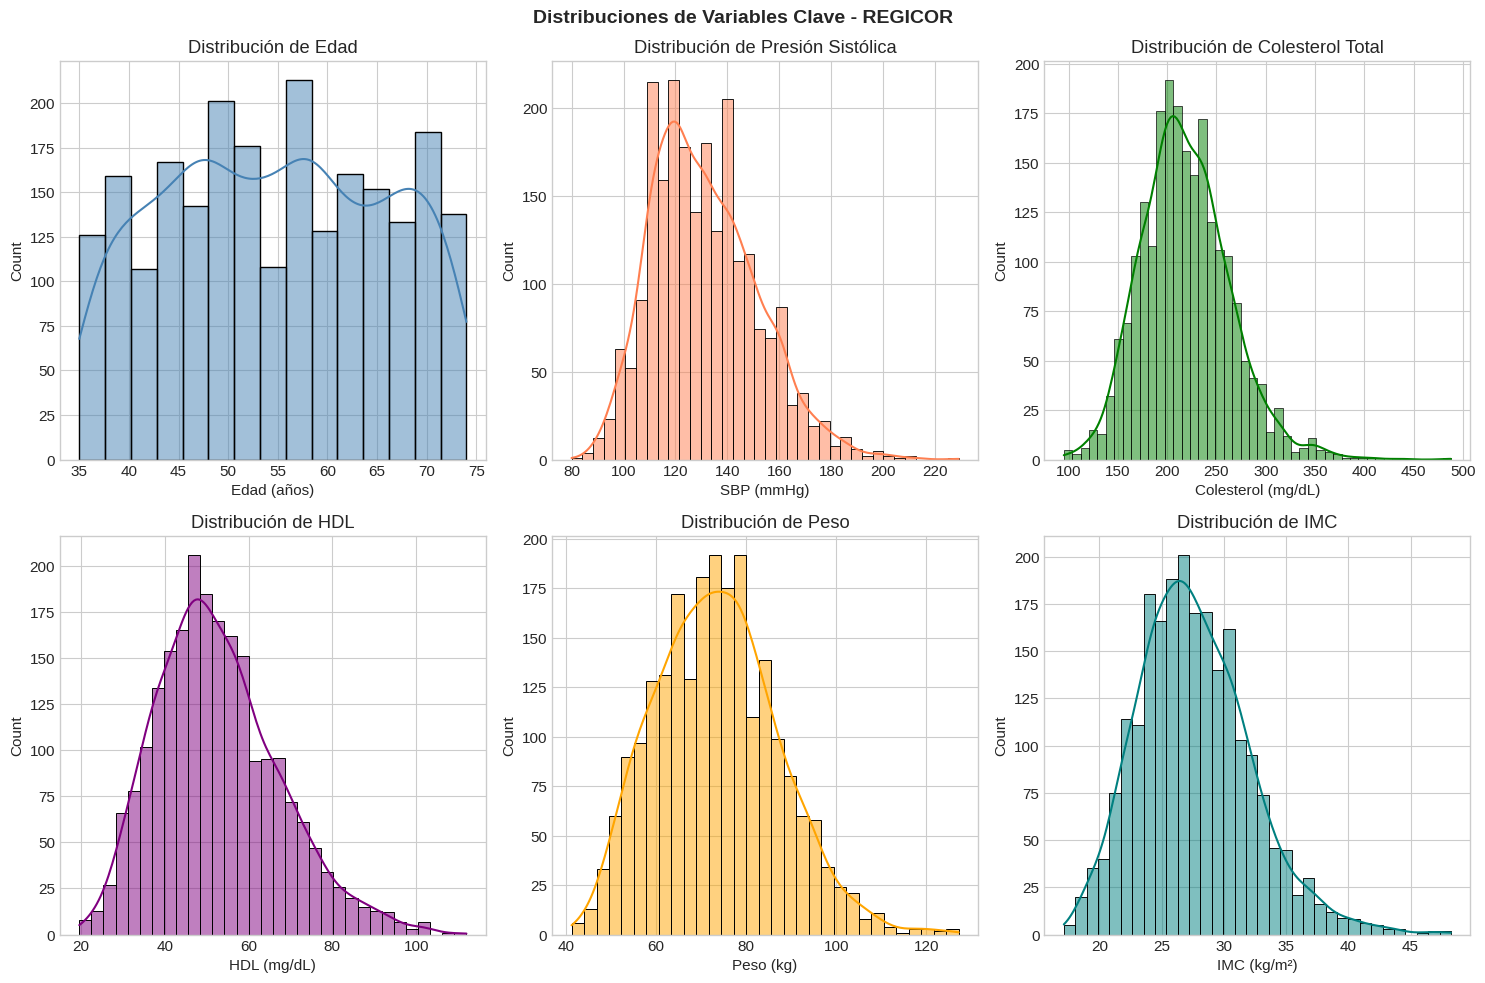

In [ ]:
# ============================================================
# 6. VISUALIZACIONES
# ============================================================
print("\n" + "="*60)
print("6. VISUALIZACIONES")
print("="*60)

# Calcular IMC
regicor['bmi'] = regicor['weight'] / (regicor['height']/100)**2

# --- Figura 1: Distribuciones ---
fig1, axes = plt.subplots(2, 3, figsize=(15, 10))
fig1.suptitle('Distribuciones de Variables Clave - REGICOR', fontsize=14, fontweight='bold')

sns.histplot(data=regicor, x='age', kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribución de Edad')
axes[0,0].set_xlabel('Edad (años)')

sns.histplot(data=regicor, x='sbp', kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('Distribución de Presión Sistólica')
axes[0,1].set_xlabel('SBP (mmHg)')

sns.histplot(data=regicor, x='chol', kde=True, ax=axes[0,2], color='green')
axes[0,2].set_title('Distribución de Colesterol Total')
axes[0,2].set_xlabel('Colesterol (mg/dL)')

sns.histplot(data=regicor, x='hdl', kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('Distribución de HDL')
axes[1,0].set_xlabel('HDL (mg/dL)')

sns.histplot(data=regicor, x='weight', kde=True, ax=axes[1,1], color='orange')
axes[1,1].set_title('Distribución de Peso')
axes[1,1].set_xlabel('Peso (kg)')

sns.histplot(data=regicor, x='bmi', kde=True, ax=axes[1,2], color='teal')
axes[1,2].set_title('Distribución de IMC')
axes[1,2].set_xlabel('IMC (kg/m²)')

plt.tight_layout()
plt.show()

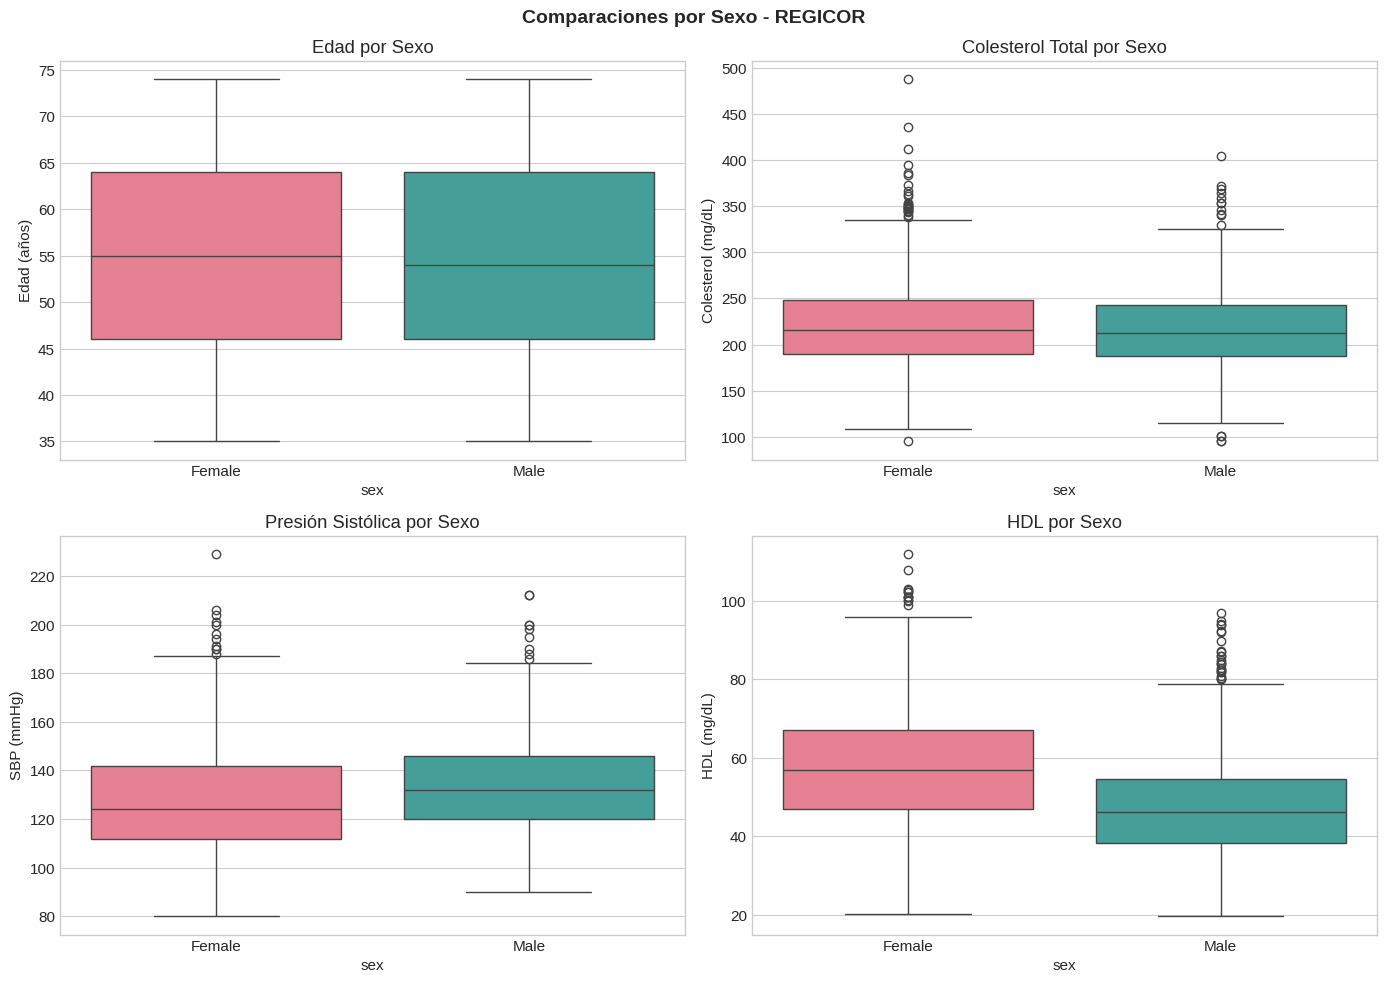

In [ ]:

# --- Figura 2: Comparaciones por sexo ---
fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Comparaciones por Sexo - REGICOR', fontsize=14, fontweight='bold')

sns.boxplot(data=df, x='sex', y='age', ax=axes[0,0], palette='husl')
axes[0,0].set_title('Edad por Sexo')
axes[0,0].set_ylabel('Edad (años)')

sns.boxplot(data=df, x='sex', y='chol', ax=axes[0,1], palette='husl')
axes[0,1].set_title('Colesterol Total por Sexo')
axes[0,1].set_ylabel('Colesterol (mg/dL)')

sns.boxplot(data=regicor, x='sex', y='sbp', ax=axes[1,0], palette='husl')
axes[1,0].set_title('Presión Sistólica por Sexo')
axes[1,0].set_ylabel('SBP (mmHg)')

sns.boxplot(data=regicor, x='sex', y='hdl', ax=axes[1,1], palette='husl')
axes[1,1].set_title('HDL por Sexo')
axes[1,1].set_ylabel('HDL (mg/dL)')

plt.tight_layout()
plt.show()

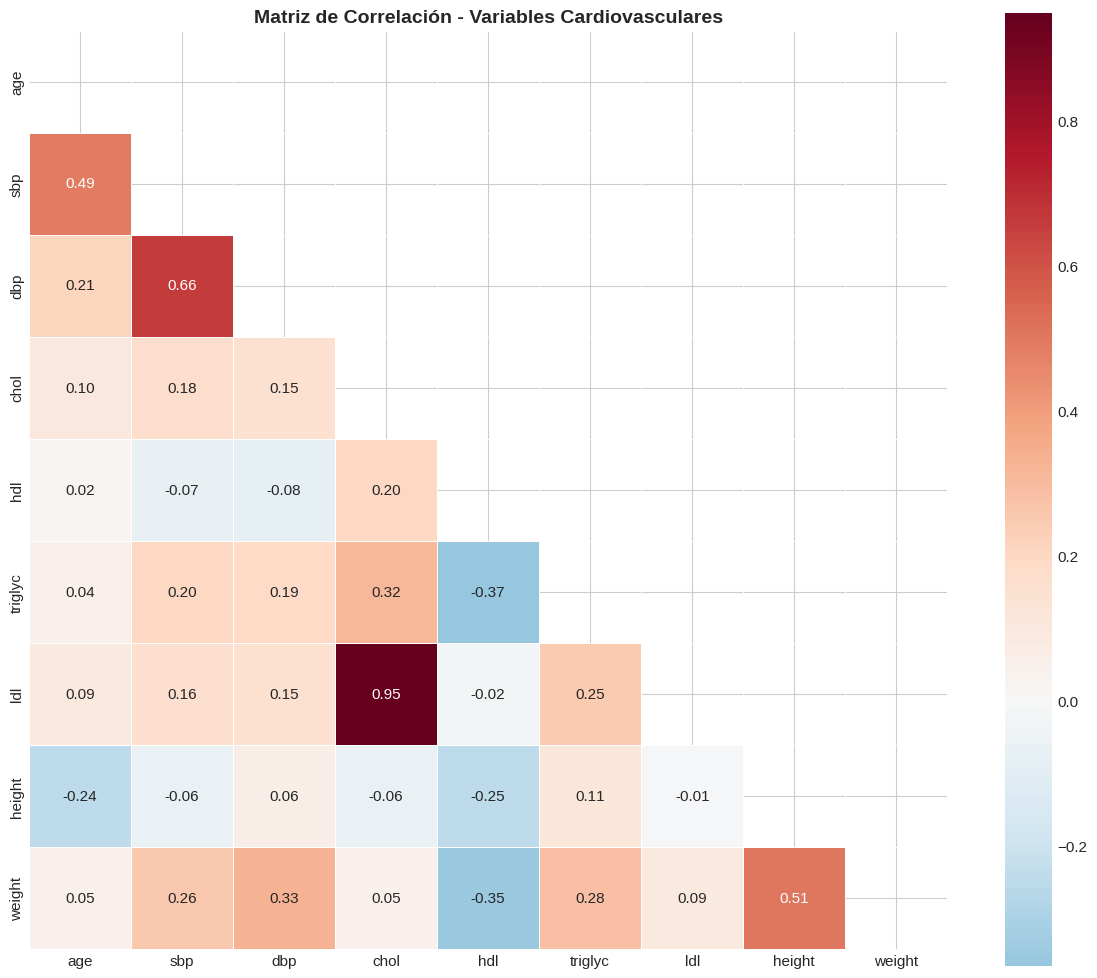

In [ ]:


# --- Figura 3: Matriz de correlación ---
fig3, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlación - Variables Cardiovasculares', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


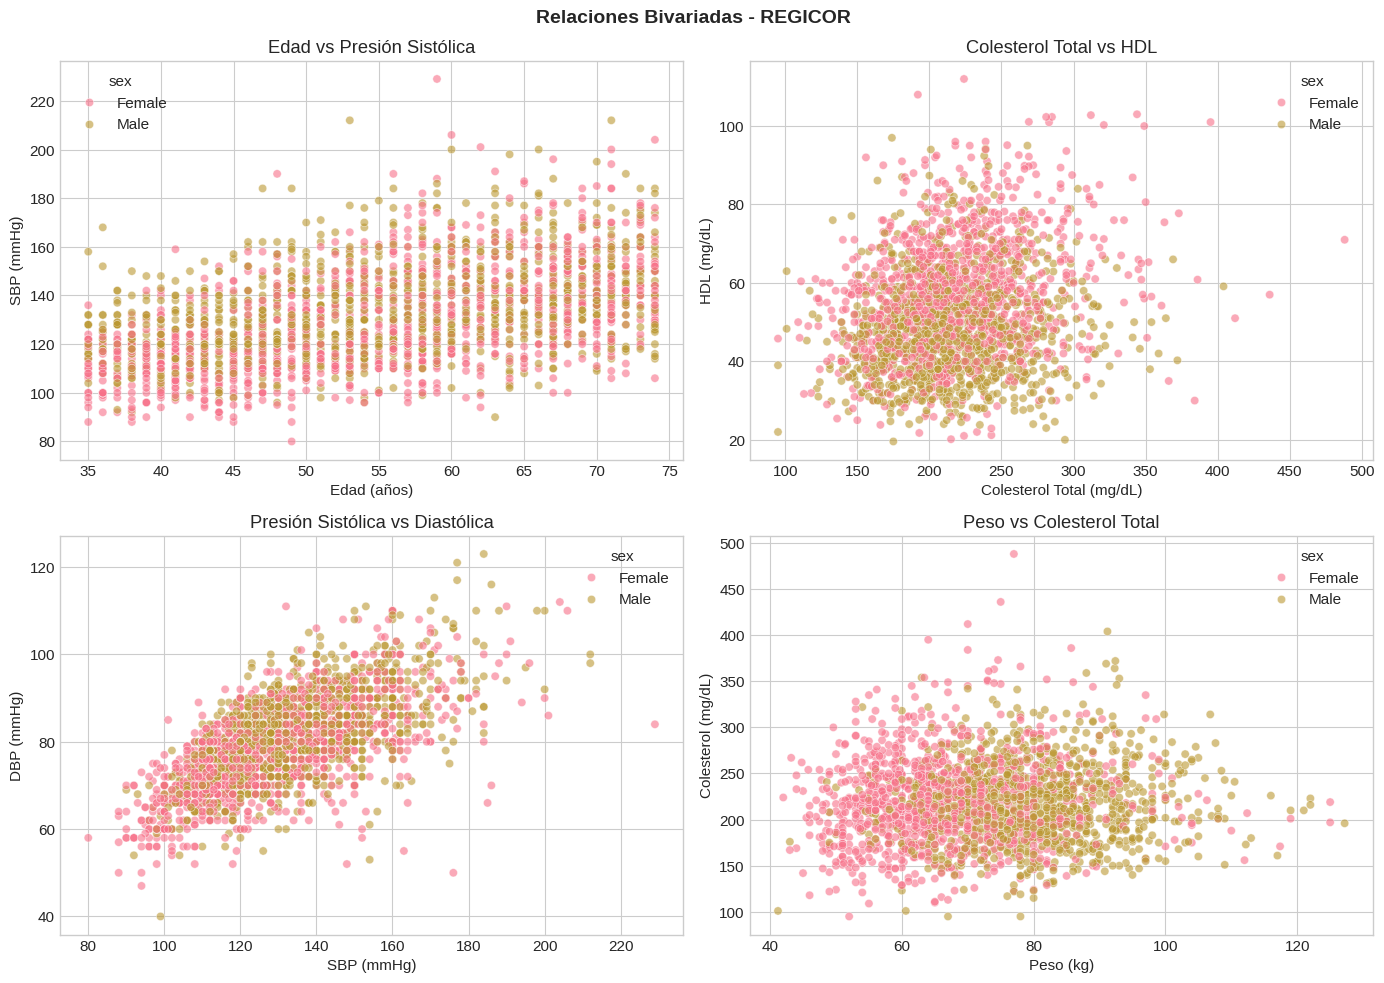

In [ ]:

# --- Figura 4: Relaciones bivariadas ---
fig4, axes = plt.subplots(2, 2, figsize=(14, 10))
fig4.suptitle('Relaciones Bivariadas - REGICOR', fontsize=14, fontweight='bold')

sns.scatterplot(data=df, x='age', y='sbp', hue='sex', alpha=0.6, ax=axes[0,0])
axes[0,0].set_title('Edad vs Presión Sistólica')
axes[0,0].set_xlabel('Edad (años)')
axes[0,0].set_ylabel('SBP (mmHg)')

sns.scatterplot(data=df, x='chol', y='hdl', hue='sex', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('Colesterol Total vs HDL')
axes[0,1].set_xlabel('Colesterol Total (mg/dL)')
axes[0,1].set_ylabel('HDL (mg/dL)')

sns.scatterplot(data=regicor, x='sbp', y='dbp', hue='sex', alpha=0.6, ax=axes[1,0])
axes[1,0].set_title('Presión Sistólica vs Diastólica')
axes[1,0].set_xlabel('SBP (mmHg)')
axes[1,0].set_ylabel('DBP (mmHg)')

sns.scatterplot(data=regicor, x='weight', y='chol', hue='sex', alpha=0.6, ax=axes[1,1])
axes[1,1].set_title('Peso vs Colesterol Total')
axes[1,1].set_xlabel('Peso (kg)')
axes[1,1].set_ylabel('Colesterol (mg/dL)')

plt.tight_layout()
plt.show()


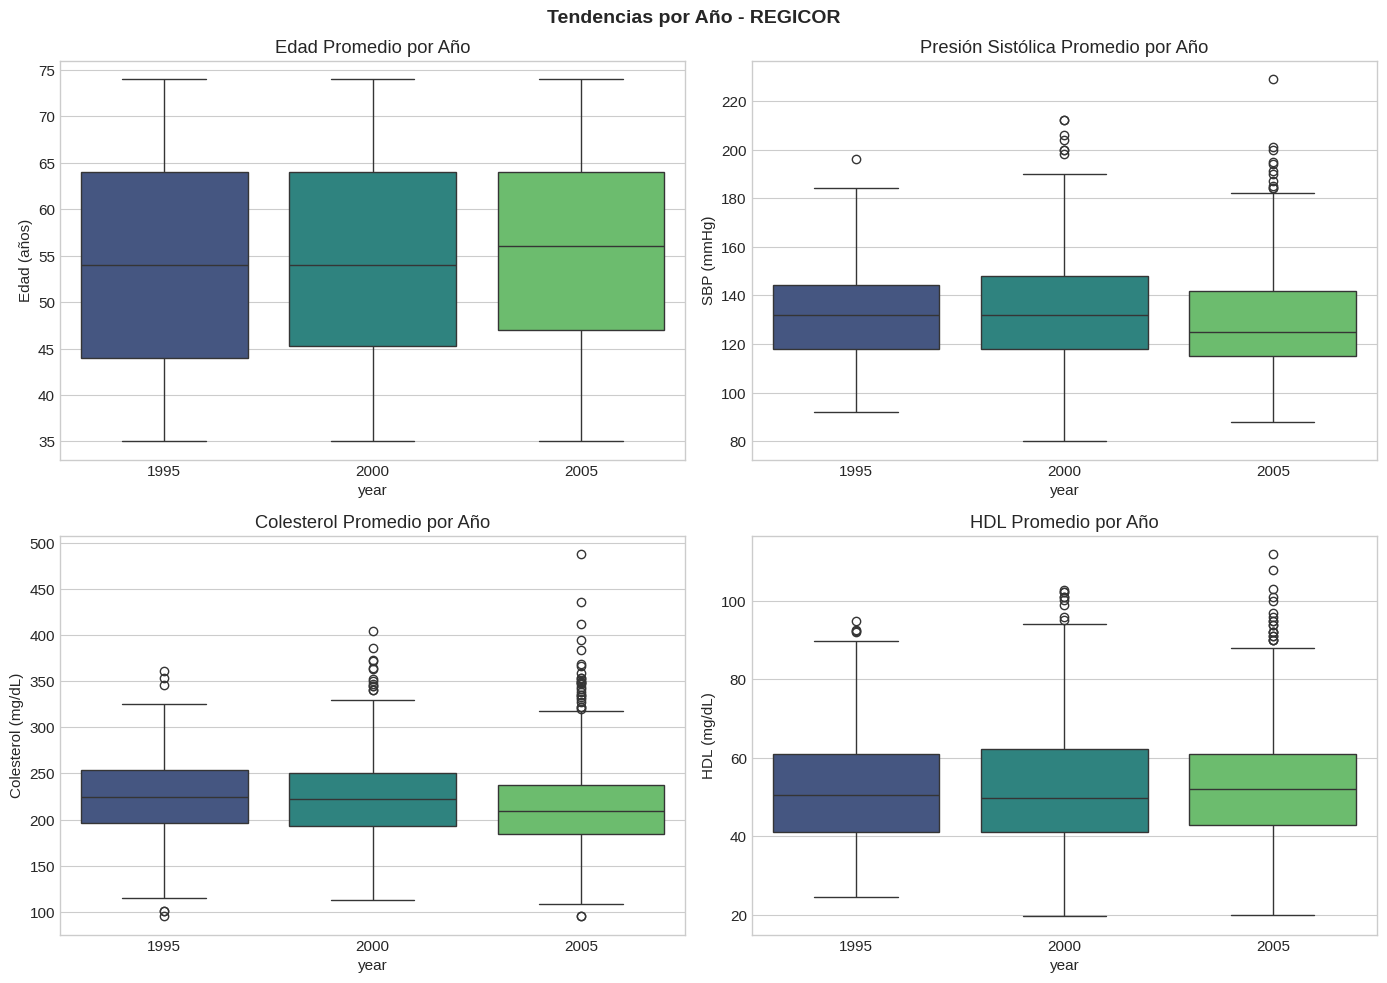

In [ ]:

# --- Figura 5: Tendencias por año ---
fig5, axes = plt.subplots(2, 2, figsize=(14, 10))
fig5.suptitle('Tendencias por Año - REGICOR', fontsize=14, fontweight='bold')


sns.boxplot(data=regicor, x='year', y='age', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Edad Promedio por Año')
axes[0,0].set_ylabel('Edad (años)')

sns.boxplot(data=regicor, x='year', y='sbp', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Presión Sistólica Promedio por Año')
axes[0,1].set_ylabel('SBP (mmHg)')

sns.boxplot(data=regicor, x='year', y='chol', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Colesterol Promedio por Año')
axes[1,0].set_ylabel('Colesterol (mg/dL)')

sns.boxplot(data=regicor, x='year', y='hdl', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('HDL Promedio por Año')
axes[1,1].set_ylabel('HDL (mg/dL)')

plt.tight_layout()
plt.show()

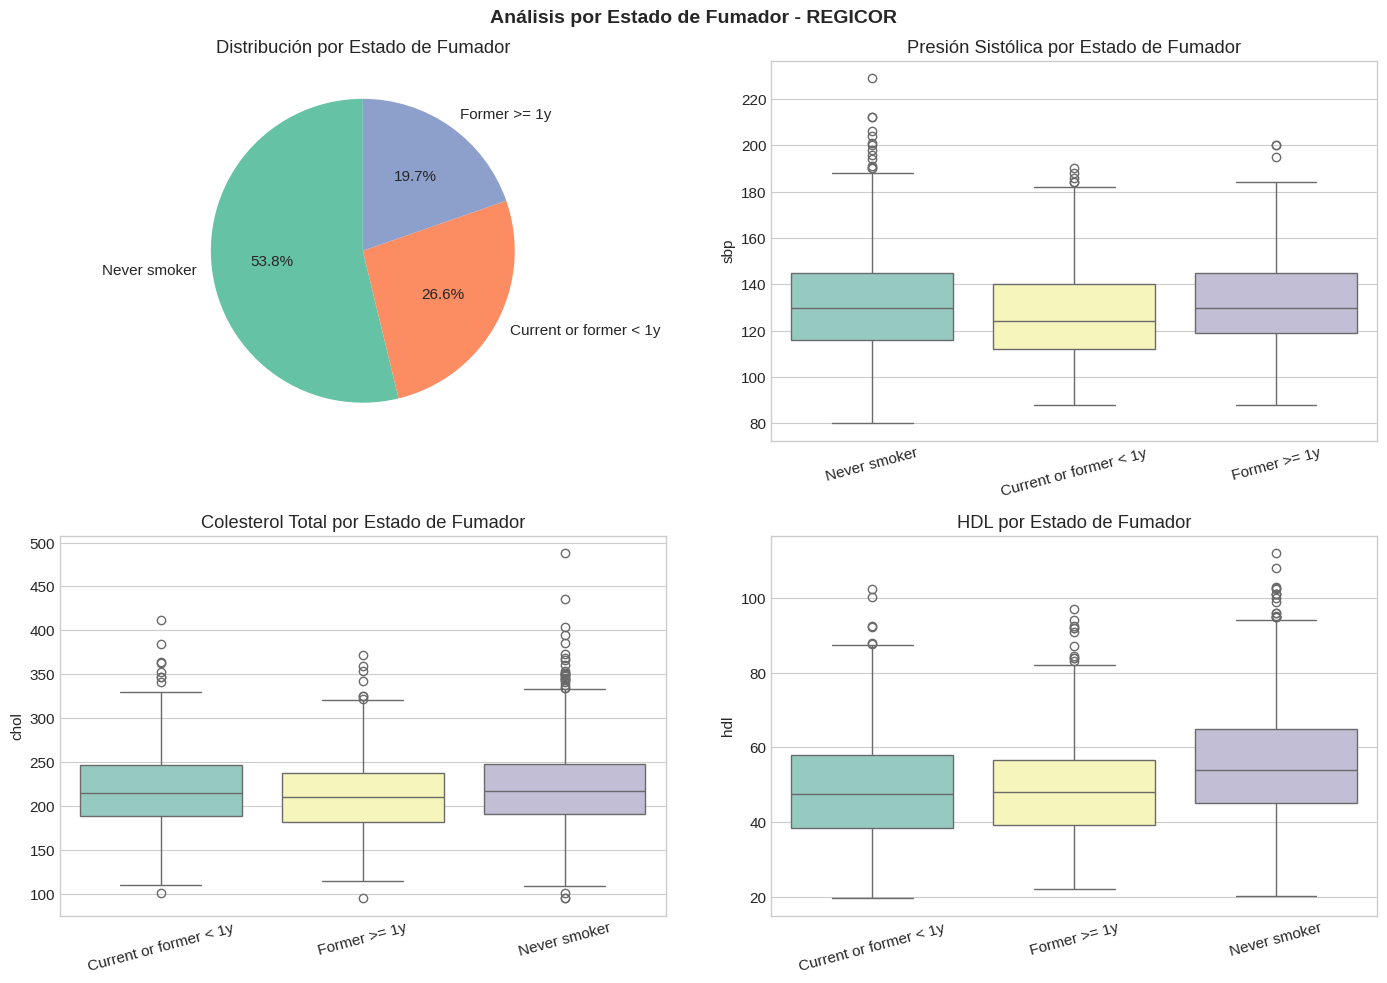

In [ ]:


# --- Figura 6: Análisis de fumadores ---
fig6, axes = plt.subplots(2, 2, figsize=(14, 10))
fig6.suptitle('Análisis por Estado de Fumador - REGICOR', fontsize=14, fontweight='bold')

smoker_counts = df['smoker'].value_counts()
colors = sns.color_palette('Set2', len(smoker_counts))
axes[0,0].pie(smoker_counts, labels=smoker_counts.index, autopct='%1.1f%%',
              colors=colors, startangle=90)
axes[0,0].set_title('Distribución por Estado de Fumador')

sns.boxplot(data=df, x='smoker', y='sbp', ax=axes[0,1], palette='Set3')
axes[0,1].set_title('Presión Sistólica por Estado de Fumador')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=15)

sns.boxplot(data=regicor, x='smoker', y='chol', ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Colesterol Total por Estado de Fumador')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=15)

sns.boxplot(data=regicor, x='smoker', y='hdl', ax=axes[1,1], palette='Set3')
axes[1,1].set_title('HDL por Estado de Fumador')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

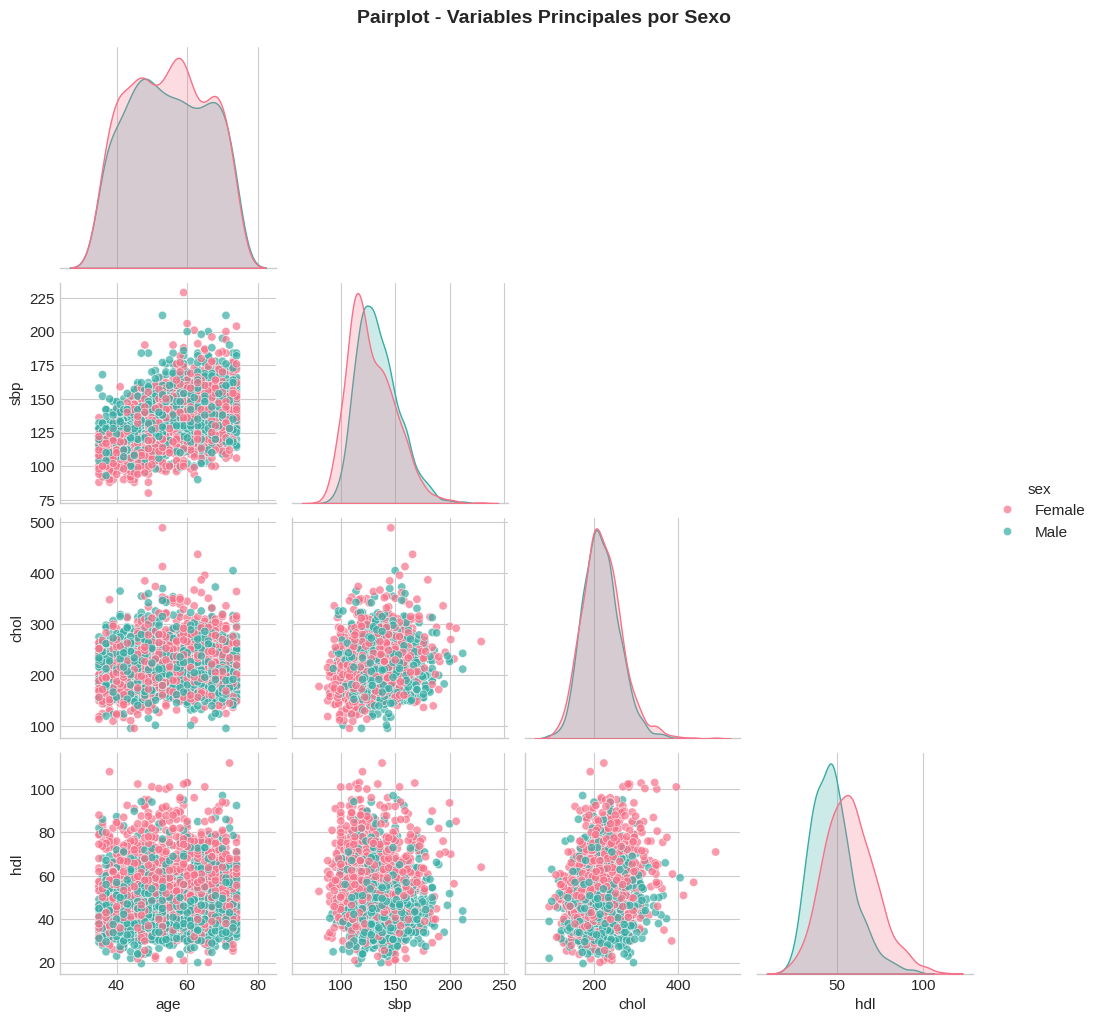

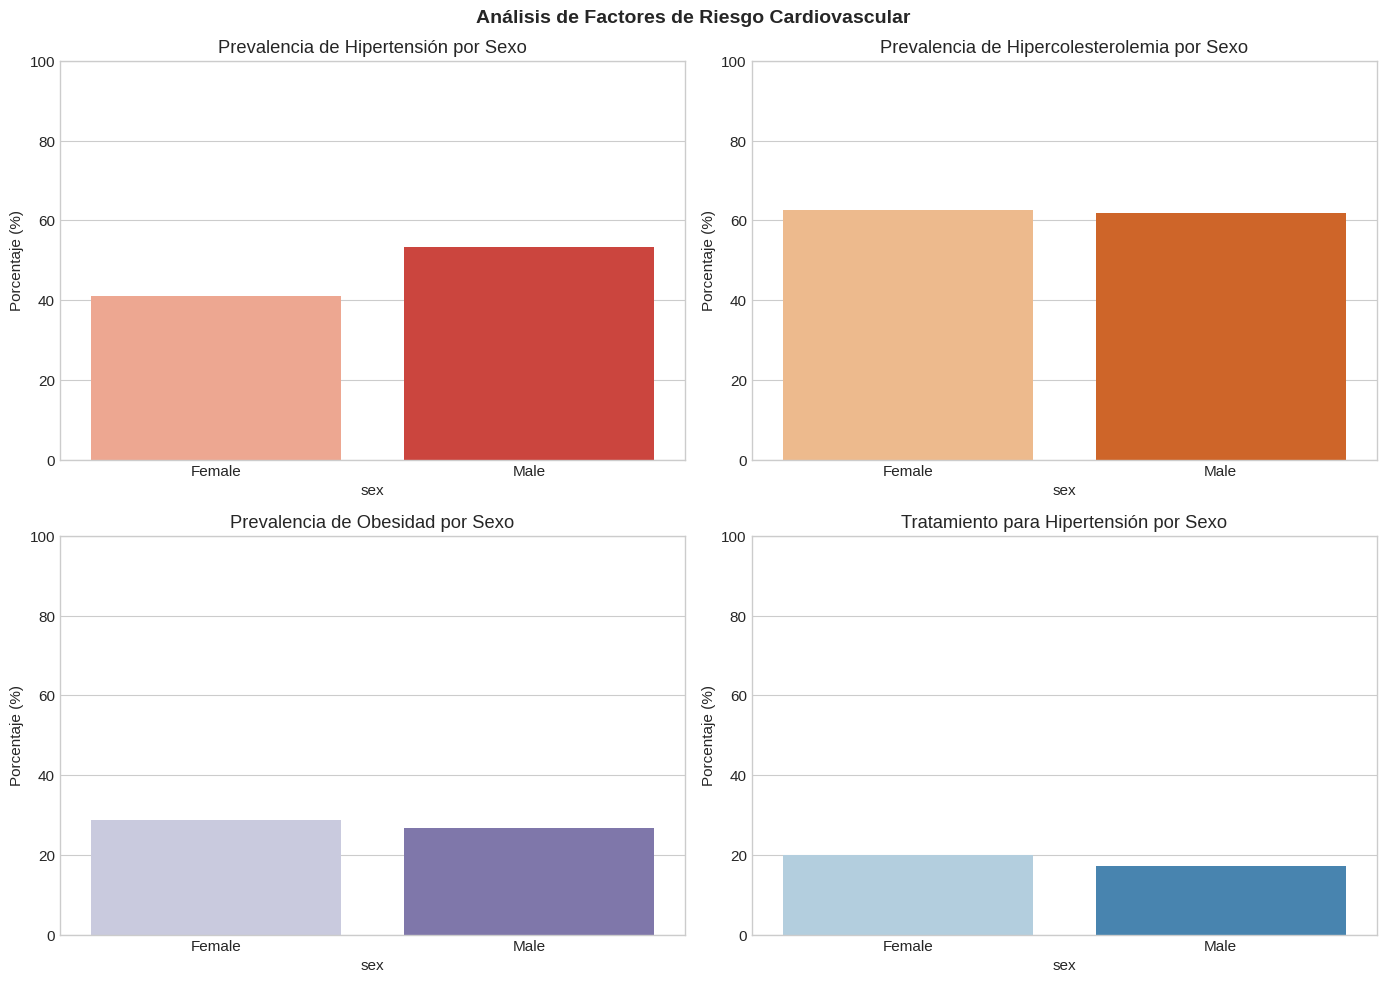

In [ ]:


# --- Figura 7: Pairplot ---
regicor_pair = regicor[['age', 'sbp', 'chol', 'hdl', 'sex']].dropna()
sns.pairplot(regicor_pair, hue='sex', diag_kind='kde', corner=True, palette= 'husl',
             plot_kws={'alpha': 0.7}, height=2.5)
plt.suptitle('Pairplot - Variables Principales por Sexo', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# --- Figura 8: Factores de riesgo cardiovascular ---
fig8, axes = plt.subplots(2, 2, figsize=(14, 10))
fig8.suptitle('Análisis de Factores de Riesgo Cardiovascular', fontsize=14, fontweight='bold')

# Definir factores de riesgo
regicor['hipertension'] = (regicor['sbp'] >= 135) | (regicor['dbp'] >= 85)
regicor['hipercol'] = regicor['chol'] >= 200
regicor['obesidad'] = regicor['bmi'] >= 30

htn_by_sex = regicor.groupby('sex')['hipertension'].mean() * 100
sns.barplot(x=htn_by_sex.index, y=htn_by_sex.values, ax=axes[0,0], palette='Reds')
axes[0,0].set_title('Prevalencia de Hipertensión por Sexo')
axes[0,0].set_ylabel('Porcentaje (%)')
axes[0,0].set_ylim(0, 100)

col_by_sex = regicor.groupby('sex')['hipercol'].mean() * 100
sns.barplot(x=col_by_sex.index, y=col_by_sex.values, ax=axes[0,1], palette='Oranges')
axes[0,1].set_title('Prevalencia de Hipercolesterolemia por Sexo')
axes[0,1].set_ylabel('Porcentaje (%)')
axes[0,1].set_ylim(0, 100)

obesity_by_sex = regicor.groupby('sex')['obesidad'].mean() * 100
sns.barplot(x=obesity_by_sex.index, y=obesity_by_sex.values, ax=axes[1,0], palette='Purples')
axes[1,0].set_title('Prevalencia de Obesidad por Sexo')
axes[1,0].set_ylabel('Porcentaje (%)')
axes[1,0].set_ylim(0, 100)

txhtn_by_sex = regicor.groupby('sex')['txhtn'].apply(lambda x: (x == 'Yes').mean() * 100)
sns.barplot(x=txhtn_by_sex.index, y=txhtn_by_sex.values, ax=axes[1,1], palette='Blues')
axes[1,1].set_title('Tratamiento para Hipertensión por Sexo')
axes[1,1].set_ylabel('Porcentaje (%)')
axes[1,1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:


# ============================================================
# 7. RESUMEN FINAL
# ============================================================
print("\n" + "="*60)
print("7. RESUMEN ESTADÍSTICO FINAL")
print("="*60)

print("\n--- CARACTERÍSTICAS DE LA POBLACIÓN ---")
print(f"Total de participantes: {len(df)}")
print(f"Mujeres: {(df['sex'] == 'Female').sum()} ({(regicor['sex'] == 'Female').mean()*100:.1f}%)")
print(f"Hombres: {(regicor['sex'] == 'Male').sum()} ({(regicor['sex'] == 'Male').mean()*100:.1f}%)")
print(f"\nEdad promedio: {regicor['age'].mean():.1f} años (DE: {regicor['age'].std():.1f})")
print(f"Rango de edad: {regicor['age'].min():.0f} - {regicor['age'].max():.0f} años")

print("\n--- PARÁMETROS CARDIOVASCULARES ---")
print(f"Presión sistólica media: {regicor['sbp'].mean():.1f} mmHg (DE: {regicor['sbp'].std():.1f})")
print(f"Presión diastólica media: {regicor['dbp'].mean():.1f} mmHg (DE: {regicor['dbp'].std():.1f})")
print(f"Colesterol total medio: {regicor['chol'].mean():.1f} mg/dL (DE: {regicor['chol'].std():.1f})")
print(f"HDL medio: {regicor['hdl'].mean():.1f} mg/dL (DE: {regicor['hdl'].std():.1f})")
print(f"LDL medio: {regicor['ldl'].mean():.1f} mg/dL (DE: {regicor['ldl'].std():.1f})")
print(f"Triglicéridos medios: {regicor['triglyc'].mean():.1f} mg/dL (DE: {regicor['triglyc'].std():.1f})")

print("\n--- FACTORES DE RIESGO ---")
print(f"Prevalencia de hipertensión: {regicor['hipertension'].mean()*100:.1f}%")
print(f"Prevalencia de hipercolesterolemia: {regicor['hipercol'].mean()*100:.1f}%")
print(f"Prevalencia de obesidad: {regicor['obesidad'].mean()*100:.1f}%")
print(f"IMC promedio: {regicor['bmi'].mean():.1f} kg/m²")

current_smokers = regicor['smoker'].isin(['Current or former < 1y']).mean() * 100
print(f"Fumadores actuales: {current_smokers:.1f}%")

print("\n" + "="*60)
print("="*60)


7. RESUMEN ESTADÍSTICO FINAL

--- CARACTERÍSTICAS DE LA POBLACIÓN ---
Total de participantes: 2294
Mujeres: 1193 (52.0%)
Hombres: 1101 (48.0%)

Edad promedio: 54.7 años (DE: 11.0)
Rango de edad: 35 - 74 años

--- PARÁMETROS CARDIOVASCULARES ---
Presión sistólica media: 131.2 mmHg (DE: 20.3)
Presión diastólica media: 79.7 mmHg (DE: 10.5)
Colesterol total medio: 218.8 mg/dL (DE: 45.2)
HDL medio: 52.7 mg/dL (DE: 14.7)
LDL medio: 143.2 mg/dL (DE: 39.7)
Triglicéridos medios: 115.6 mg/dL (DE: 73.9)

--- FACTORES DE RIESGO ---
Prevalencia de hipertensión: 47.0%
Prevalencia de hipercolesterolemia: 62.2%
Prevalencia de obesidad: 27.8%
IMC promedio: 27.6 kg/m²
Fumadores actuales: 25.9%

